# Garch Model for Volatility Fitting

This project aims to fit Garch(1,1) volatility models for some major global quity indices (S&P 500, EURO STOXX 50, Nikkei 225, FTSE 100)

The project uses data from 2010-01-01 to 2026-05-28, and the data is loaded in the data folder

- Key steps:
    - Fetch Data from Yahoo Finance
    - Calculate out the log return
    - Check Stationary for each series
    - EDA 
    - Model Fitting
    - Model Interpretation and Evaluation



# Step 1 Data Fetching

In [1]:
# load the required packages
import pandas as pd
import numpy as np
from pathlib import Path
import yfinance as yf

# Output directory for exported figures and tables.
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
#^GSPC: S&P 500 Index; ^STOXX50E: EURO STOXX 50 Index; 
#^N225: Nikkei 225 Index; ^FTSE: FTSE 100 Index
indices = ["^GSPC", "^STOXX50E", "^N225", "^FTSE"]
start_date='2010-01-01'
end_date='2026-05-28'

data=yf.download(indices,start=start_date,end=end_date,auto_adjust=True)['Close']
#Write the data into data folder:
# data.to_csv('../data/data.csv')
data.head()

[*********************100%***********************]  4 of 4 completed


Ticker,^FTSE,^GSPC,^N225,^STOXX50E
Date,,,,
2010-01-04,5500.299805,1132.989990,10654.790039,3017.800049
2010-01-05,5522.500000,1136.520020,10681.830078,3012.360107
2010-01-06,5530.000000,1137.140015,10731.450195,3009.659912
2010-01-07,5526.700195,1141.689941,10681.660156,3007.340088
2010-01-08,5534.200195,1144.979980,10798.320312,3017.850098


# Step 2 Log return

In [2]:
#Get the log return series for each index
log_return_data=pd.DataFrame()
for index in data.columns:
    log_return_data[f'{index}_log_return']=np.log(data[index])-np.log(data[index].shift(1))
log_return_data.head()


,^FTSE_log_return,^GSPC_log_return,^N225_log_return,^STOXX50E_log_return
Date,,,,
2010-01-04,NaN,NaN,NaN,NaN
2010-01-05,0.004028,0.003111,0.002535,-0.001804
2010-01-06,0.001357,0.000545,0.004635,-0.000897
2010-01-07,-0.000597,0.003993,-0.004650,-0.000771
2010-01-08,0.001356,0.002878,0.010862,0.003489


# Step 3 Check on statioanrity for each Series

 - Below I used ADF to check on unit root for each series and infer the stationarity for each series.

In [3]:
from statsmodels.tsa.stattools import adfuller

for log_return in log_return_data.columns:
    print(log_return)
    result=adfuller(log_return_data[log_return].dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print(f"{log_return} is stationary")
    else:
        print(f"{log_return} is non-stationary")



^FTSE_log_return
ADF Statistic: -13.611943758690886
p-value: 1.8659636858298176e-25
^FTSE_log_return is stationary
^GSPC_log_return
ADF Statistic: -13.274284764718084
p-value: 7.922912026557013e-25
^GSPC_log_return is stationary
^N225_log_return
ADF Statistic: -65.29121888157415
p-value: 0.0
^N225_log_return is stationary
^STOXX50E_log_return
ADF Statistic: -23.794882740339677
p-value: 0.0
^STOXX50E_log_return is stationary


# Interpretation

We can see from ADF, all P-values are far below 0.05, meaning significant evidence for us to conclude that they are stationary, and hence we can continue our volatility model fitting.


# Step 4: EDA

This section produces plots of prices, returns, rolling volatility, and return distributions.

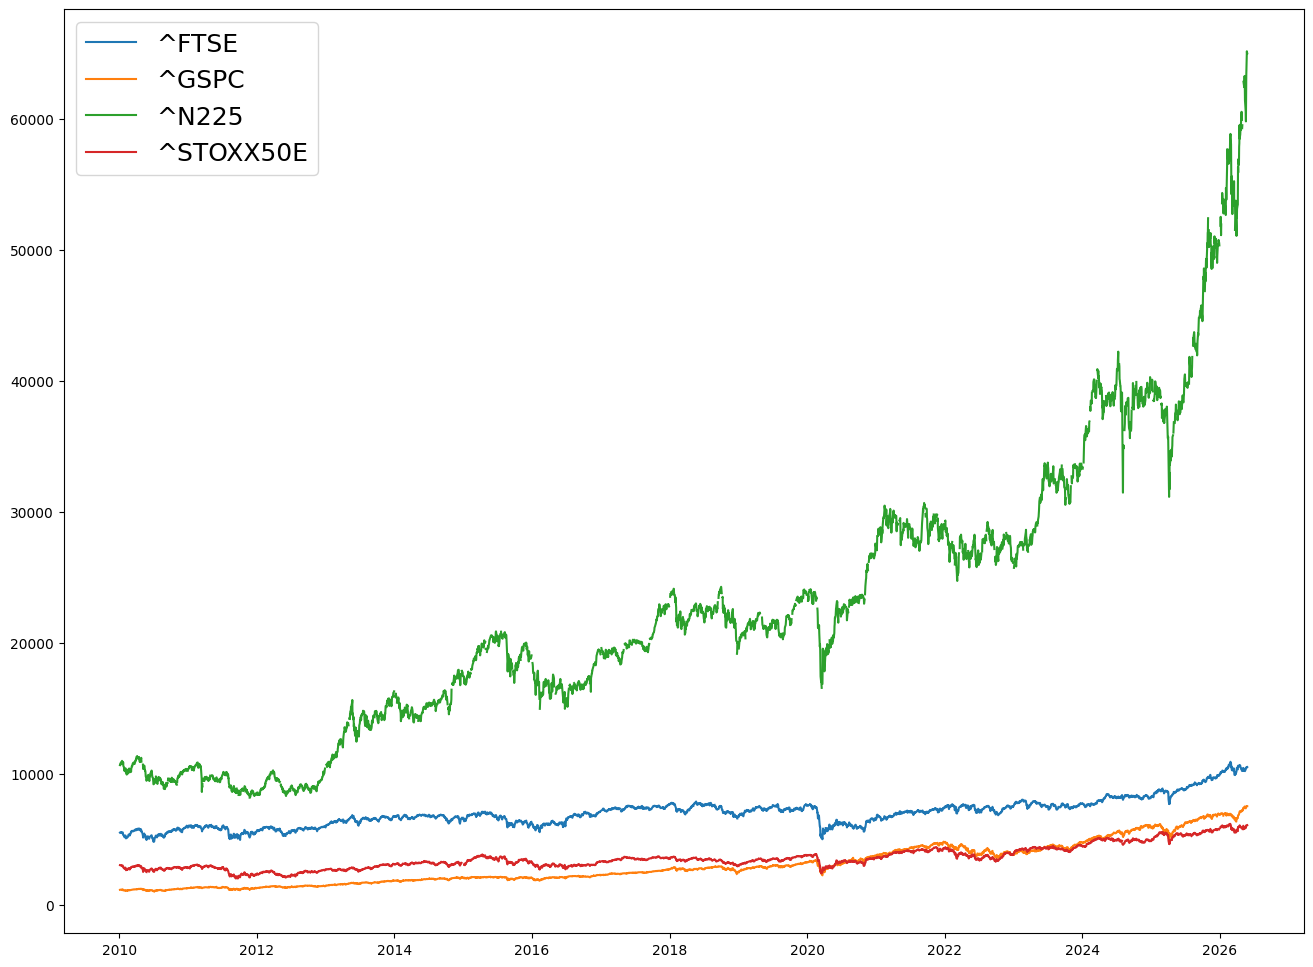

In [4]:
import matplotlib.pyplot as plt
# Price plot
plt.figure(figsize=(16,12))
for index in data.columns:
    plt.plot(data.index,data[index],label=index)
plt.legend(fontsize=18, markerscale=1.5)
# Export: ../outputs/price_plot.png
plt.savefig(OUTPUT_DIR / 'price_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## Interpretation of price plot
N225, the Nikeei 225 index shows the strongest of growth from 2010 to 2026, whereas the other three indices, especially STOXX50E and GSPC, have relatively similiar growth trajectory.

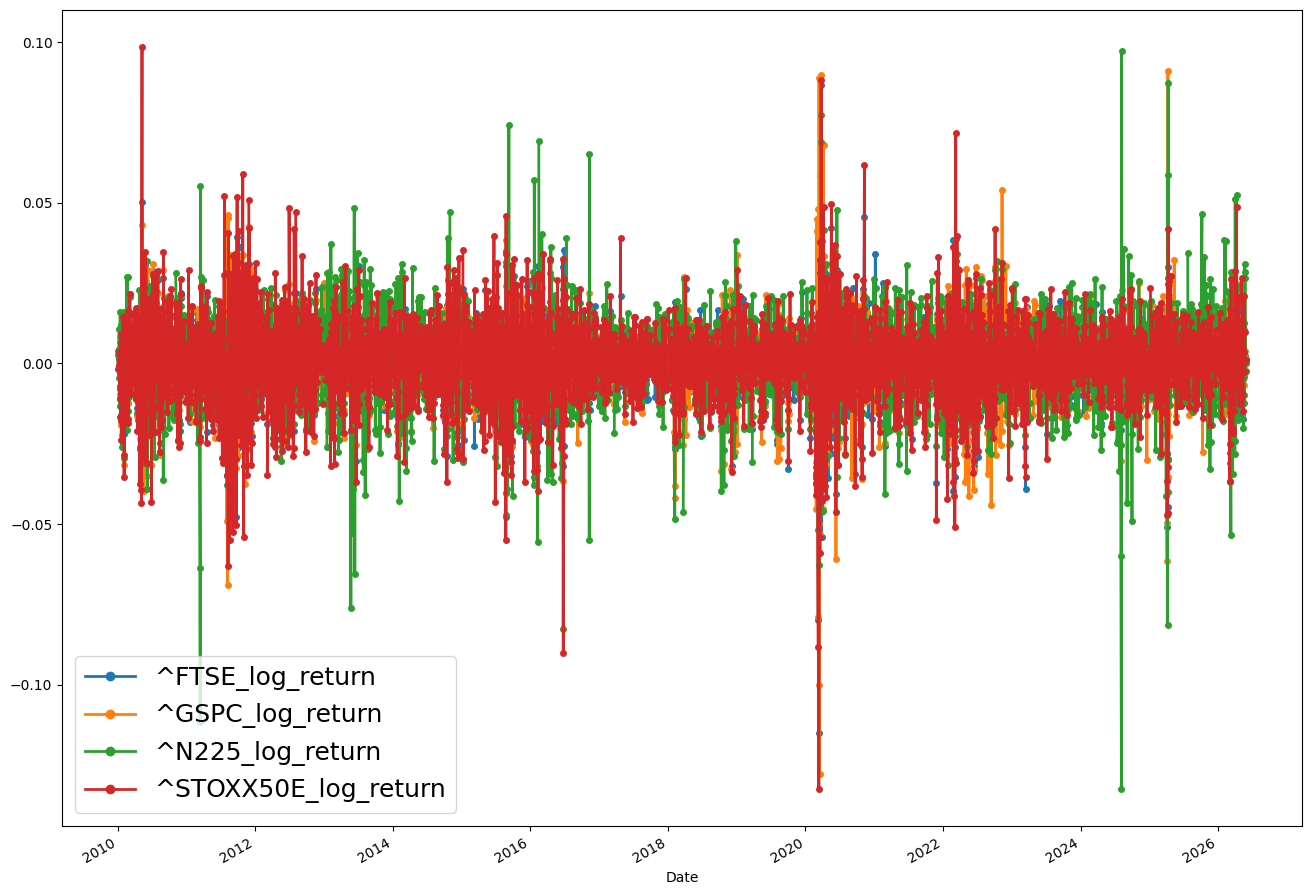

In [5]:
# Log return plot
log_return_data.plot(figsize=(16, 12),marker='o',
    markersize=4,
    linewidth=2)
plt.legend(fontsize=18, markerscale=1.5)
# Export: ../outputs/log_return_plot.png
plt.savefig(OUTPUT_DIR / 'log_return_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretation of return plot
We can see that the return for each series osciallate between 0, which fits our expectation. 

Also, just by visual inspection, we can see there is not an obivious trend and hence it indicates that the stationarity assumption is likely to hold(which we validate in the last section)

Returns from STOXX50E and N225 show a much higher volatility than the rest two indices.

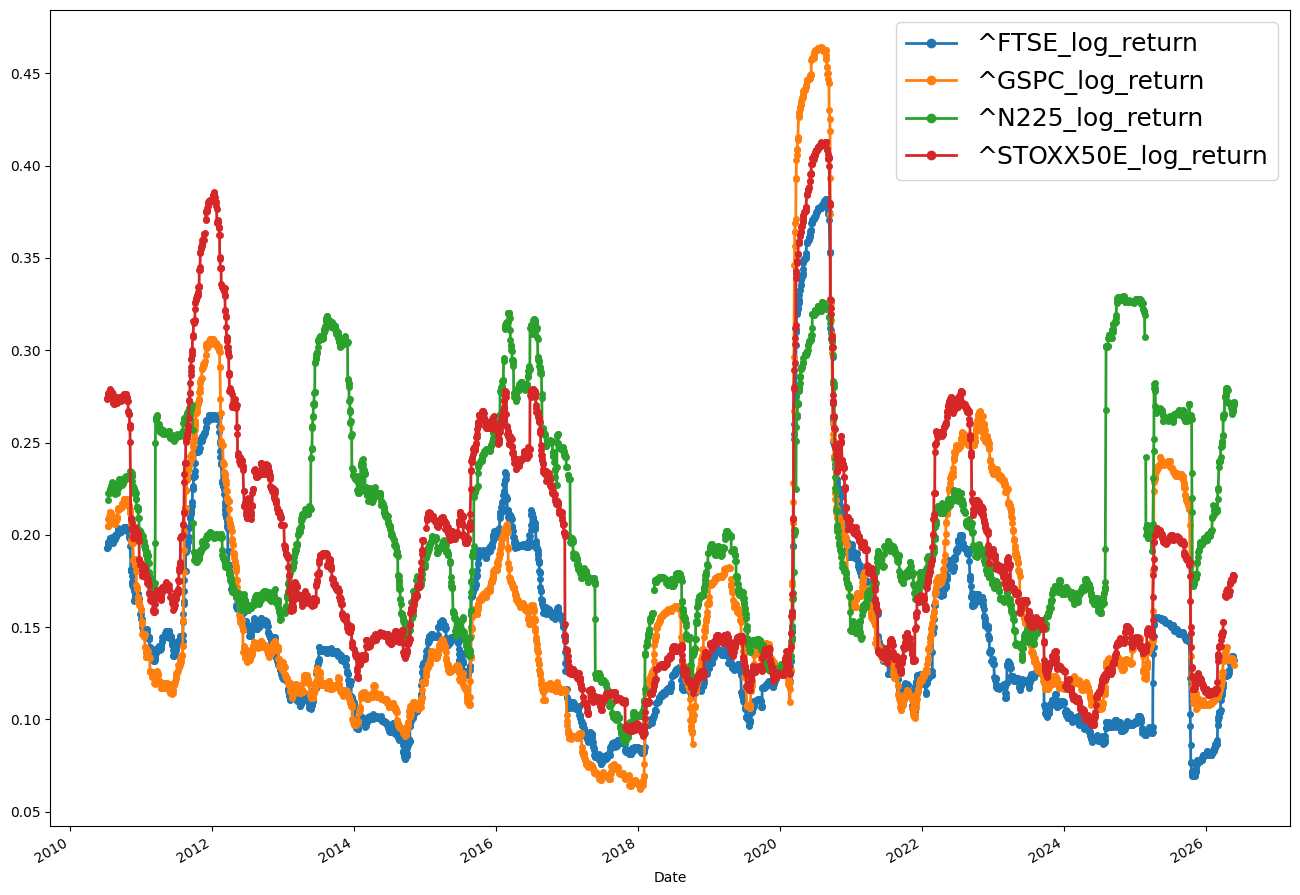

                      ^FTSE_log_return  ^GSPC_log_return  ^N225_log_return  \
^FTSE_log_return              1.000000          0.885697          0.435442   
^GSPC_log_return              0.885697          1.000000          0.394390   
^N225_log_return              0.435442          0.394390          1.000000   
^STOXX50E_log_return          0.933813          0.822952          0.434243   

                      ^STOXX50E_log_return  
^FTSE_log_return                  0.933813  
^GSPC_log_return                  0.822952  
^N225_log_return                  0.434243  
^STOXX50E_log_return              1.000000  


In [6]:
#Rolling Volatility

#Here I will calculate the rolling volatility using 
#a time window of 126(half of total trading days in a year)
#Calculate out the annual volatility by timing sqrt(252) with daily vol
rolling_vol = pd.DataFrame(
    {
        col: log_return_data[col].dropna().rolling(window=126).std() * np.sqrt(252)
        for col in log_return_data.columns
    }
)

#Volatility Plot
rolling_vol.plot(figsize=(16, 12),marker='o',
    markersize=4,
    linewidth=2)
plt.legend(fontsize=18, markerscale=1.5)
# Export: ../outputs/rolling_volatility_plot.png
plt.savefig(OUTPUT_DIR / 'rolling_volatility_plot.png', dpi=300, bbox_inches='tight')
plt.show()

#Correlatin matrix for the rolling volatility
corr_matrix = rolling_vol.corr()
# Export: ../outputs/rolling_volatility_series.csv and ../outputs/rolling_volatility_correlation.csv
rolling_vol.to_csv(OUTPUT_DIR / 'rolling_volatility_series.csv')
corr_matrix.to_csv(OUTPUT_DIR / 'rolling_volatility_correlation.csv')
print(corr_matrix)

## Interpretation of Rolling Volatility

Several major volatility spikes are clearly visible across all four indices, indicating periods of heightened market uncertainty and financial stress. The most prominent spike occurs around 2020, corresponding to the COVID-19 pandemic, when volatility surged simultaneously across global equity markets. This synchronized increase suggests a strong contagion effect during crisis periods.

The rolling volatility series for FTSE, GSPC, and STOXX50E appear to be highly correlated, with volatility rising and falling in a similar pattern over time. This reflects the strong integration of U.S. and European financial markets.

In contrast, N225, which represents the Japanese market, exhibits a somewhat different volatility pattern and lower correlation with the other three indices. While it still experiences volatility spikes during global crises, its volatility dynamics appear to be influenced to a greater extent by domestic and regional factors.

Overall, the results provide evidence of volatility clustering, where periods of high volatility tend to be followed by further periods of high volatility.

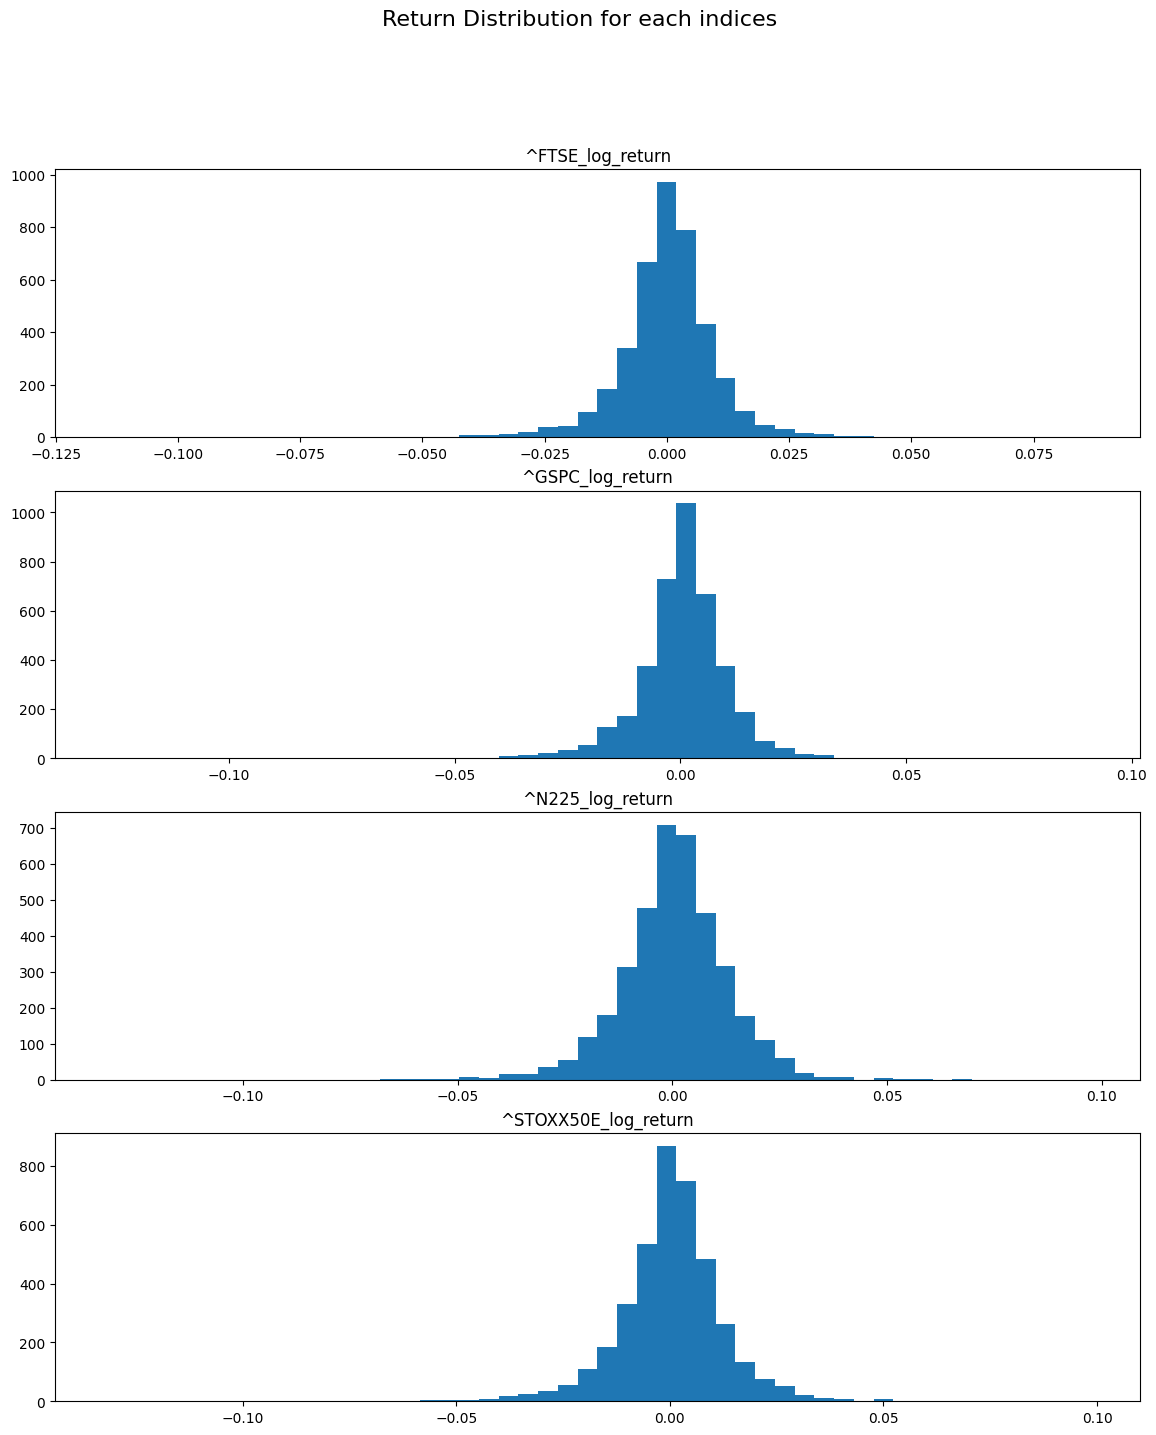

In [7]:
#Return distribution
from matplotlib.pyplot import hist

fig,axes=plt.subplots(4,1,figsize=(14,16))
fig.suptitle("Return Distribution for each indices", fontsize=16)
axes=axes.flatten()
i=0
for index_return in log_return_data.columns:
    ax=axes[i]
    i+=1
    ax.hist(log_return_data[index_return],bins=50)
    ax.set_title(index_return)
# Export: ../outputs/return_distribution.png
plt.savefig(OUTPUT_DIR / 'return_distribution.png', dpi=300, bbox_inches='tight')

# Interpretation of return distribution

All the 4 series' return distributions show a roughly normal distribution shape with mean around 0.

# Step 4: Model Fitting

## Revisit the GARCH Model

Financial returns often exhibit volatility clustering, where periods of high volatility tend to be followed by high volatility, and periods of low volatility tend to be followed by low volatility. To capture this phenomenon, we use the Generalized Autoregressive Conditional Heteroskedasticity (GARCH) model.

The return process is modeled as

$$
r_t = \mu + \epsilon_t
$$

where

$$
\epsilon_t = \sigma_t z_t,
$$

and

$$
z_t \sim N(0,1).
$$

The key feature of the GARCH model is that the conditional variance evolves over time according to past shocks and past variances.

The general GARCH(p,q) specification is

$$
\sigma_t^2
=
\omega
+
\sum_{i=1}^{q}
\alpha_i \epsilon_{t-i}^2
+
\sum_{j=1}^{p}
\beta_j \sigma_{t-j}^2.
$$

where:

- $\omega$ is the long-run variance component,
- $\alpha_i$ measures the impact of past shocks (ARCH effects),
- $\beta_j$ measures the persistence of past volatility (GARCH effects).

The most commonly used specification is the GARCH(1,1) model, which takes the form

$$
\sigma_t^2
=
\omega
+
\alpha \epsilon_{t-1}^2
+
\beta \sigma_{t-1}^2.
$$

A valid GARCH model typically requires

$$
\omega > 0,
\qquad
\alpha_i \ge 0,
\qquad
\beta_j \ge 0,
$$

and

$$
\sum_{i=1}^{q}\alpha_i
+
\sum_{j=1}^{p}\beta_j
< 1
$$

to ensure covariance stationarity.

## Maximum Likelihood Estimation (MLE)

The parameters of a GARCH model are not directly observable and must be estimated from historical return data.

To estimate these parameters, we use **Maximum Likelihood Estimation (MLE)**. The intuition behind MLE is to find the parameter values that maximize the likelihood of observing the return series under the assumed GARCH process.

Rather than implementing the optimization procedure from scratch, we use the Python package `arch`, which provides efficient routines for fitting GARCH models and estimating parameters via MLE.

In the following sections, we fit several GARCH specifications and compare their performance using information criteria such as AIC and BIC.

In [8]:
#Fitting the GARCH Model for Each Index
from arch import arch_model
garch_results={}
for col in log_return_data.columns:
    returns=log_return_data[col].dropna()
    #here use returns*100 rather than just return for better model fitting
    model=arch_model(returns*100,
                     mean='constant',
                     vol='GARCH',
                     p=1,
                     q=1,
                     dist='normal')
    result=model.fit(disp='off')
    garch_results[col]=result

#Store the fitted parameters for display
summary_table=pd.DataFrame({
    col:results.params
    for col, results in garch_results.items()
}).T
summary_table['sum of parameters']=summary_table['alpha[1]']+summary_table['beta[1]']
# Export: ../outputs/garch_normal_parameters.csv
summary_table.to_csv(OUTPUT_DIR / 'garch_normal_parameters.csv')
summary_table


,mu,omega,alpha[1],beta[1],sum of parameters
^FTSE_log_return,0.039357,0.049539,0.160974,0.785045,0.946019
^GSPC_log_return,0.083846,0.038045,0.164753,0.803007,0.967759
^N225_log_return,0.069976,0.091895,0.148092,0.804249,0.952341
^STOXX50E_log_return,0.064563,0.056341,0.135973,0.830180,0.966153


## Interpretation of models' parameters
As shown, the sum of $\alpha + \beta$ is greater than or equal to 0.94 for all four indices. This indicates strong volatility persistence, meaning that periods of high or low volatility tend to cluster over time. This result is also consistent with common empirical observations in financial markets.

# Step 5: Model Evaluation

This section will
 - Inspect the residuals and standardized residuals of our model
 - Retrain the model using Student-t distribution instead of normal distribution, as t-distribution has a fatter tail than normal distribution, which fits more of the reality.
 - Retrain models using data from 2010 to 2021, and test its forecasting performance from 2022-2026 (roughly a 70/30 split)



## Residuals Inspection

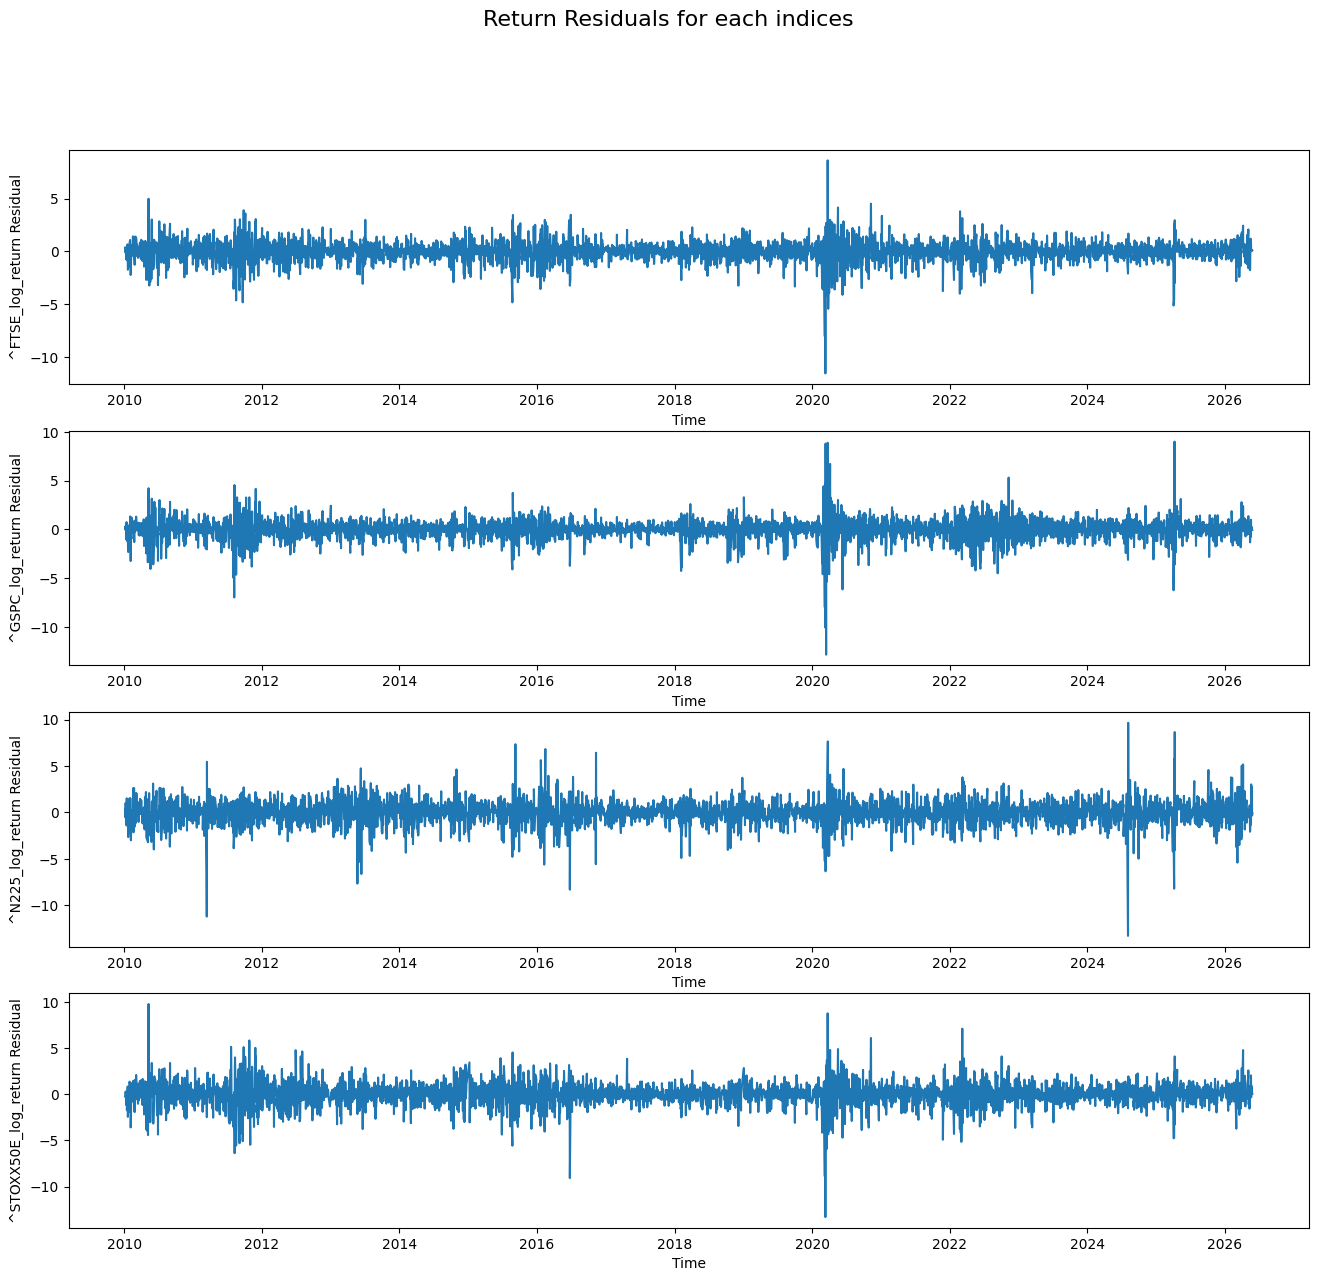

In [9]:
fig,axes=plt.subplots(4,1,figsize=(16,14))
fig.suptitle("Return Residuals for each indices", fontsize=16)
axes=axes.flatten()
i=0
#all the residuals are multiplied by 100, so a residual of 1 means 1%
for key, result in garch_results.items():
    resid = result.resid
    axes[i].plot(resid, label=key)
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel(f"{key} Residual")
    i+=1
# Export: ../outputs/residuals_plot.png
plt.savefig(OUTPUT_DIR / 'residuals_plot.png', dpi=300, bbox_inches='tight')



### Residual Interpretation

The residual plots indicate that the variance of the residuals is not constant over time. Instead, periods of high volatility tend to be followed by periods of high volatility, while periods of low volatility tend to be followed by periods of low volatility. This volatility clustering suggests the presence of conditional heteroskedasticity, which is a key motivation for using GARCH models.

As a result, examining the raw residuals alone is not sufficient. A more meaningful diagnostic is to analyze the standardized residuals,

$$
z_t = \frac{\epsilon_t}{\sigma_t},
$$

where $\epsilon_t$ denotes the residual and $\sigma_t$ is the conditional volatility estimated by the GARCH model.

If the model adequately captures the time-varying volatility, the standardized residuals should resemble white noise and exhibit approximately constant variance over time.

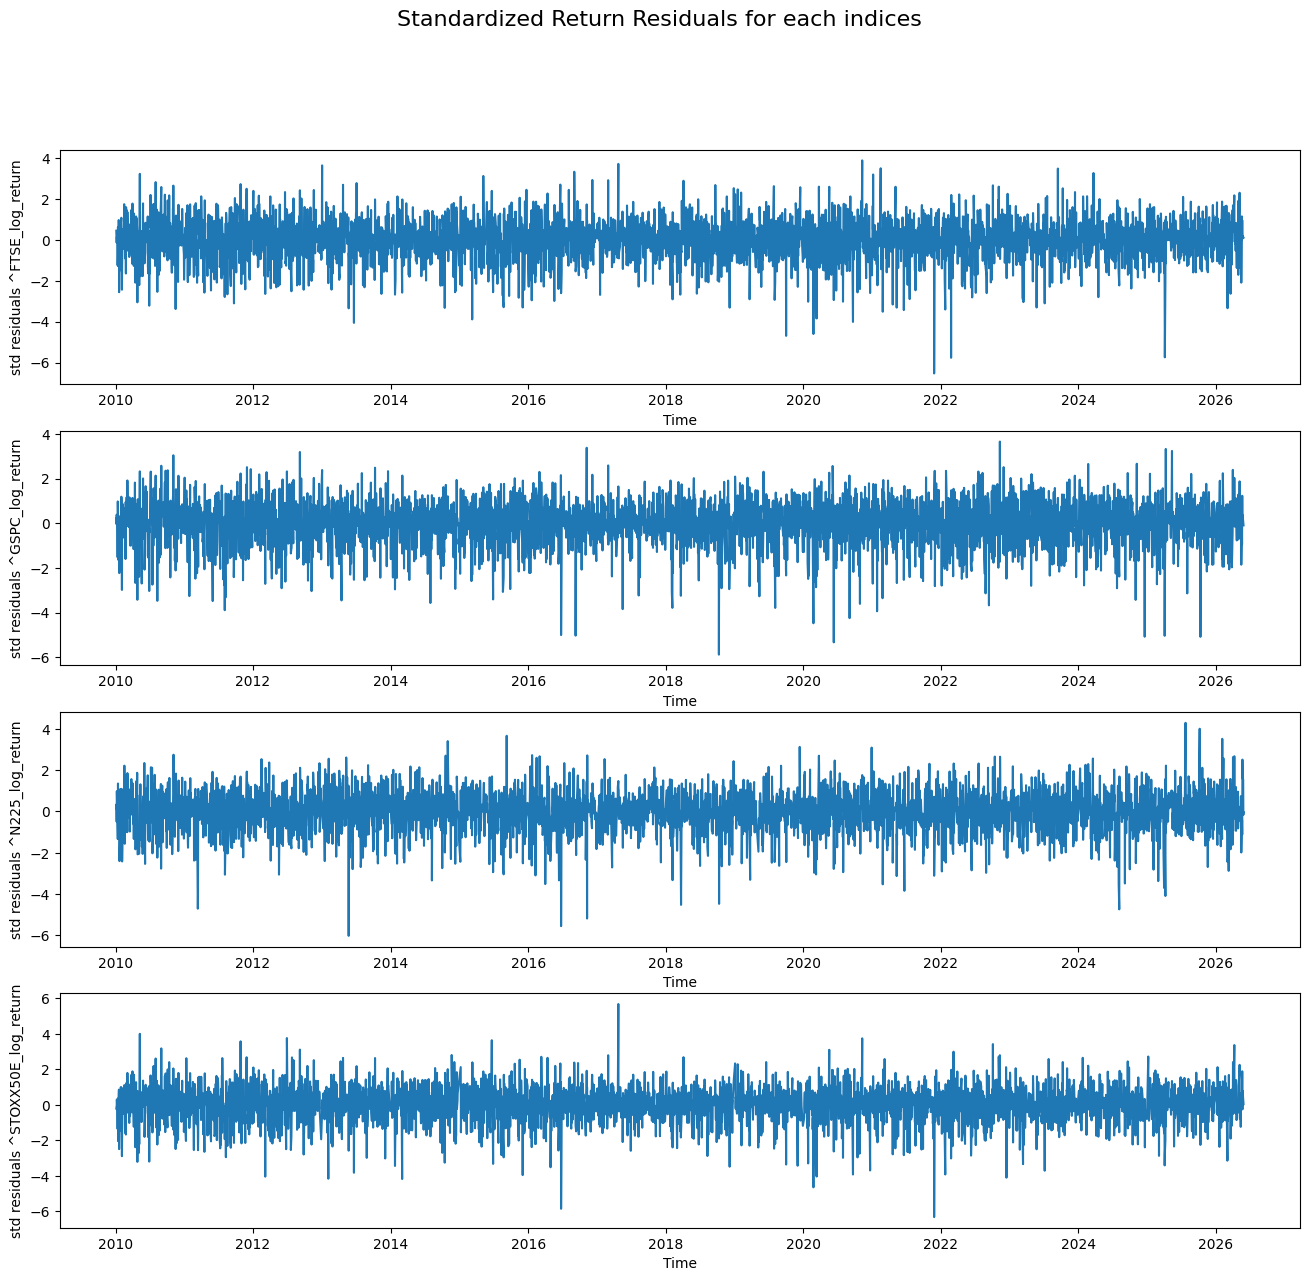

In [10]:
# Standardized Residuals
fig,axes=plt.subplots(4,1,figsize=(16,14))
fig.suptitle("Standardized Return Residuals for each indices", fontsize=16)
axes=axes.flatten()
i=0
#all the residuals are multiplied by 100, so a residual of 1 means 1%
for key, result in garch_results.items():
    sd_resid = result.resid/result.conditional_volatility
    axes[i].plot(sd_resid, label=key)
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel(f"std residuals {key}")
    i+=1
# Export: ../outputs/standardized_residuals_plot.png
plt.savefig(OUTPUT_DIR / 'standardized_residuals_plot.png', dpi=300, bbox_inches='tight')

All plots show much more consistent variation across time, which indicates the validity of the Garch model.

### ACF plot of standardzied residuals

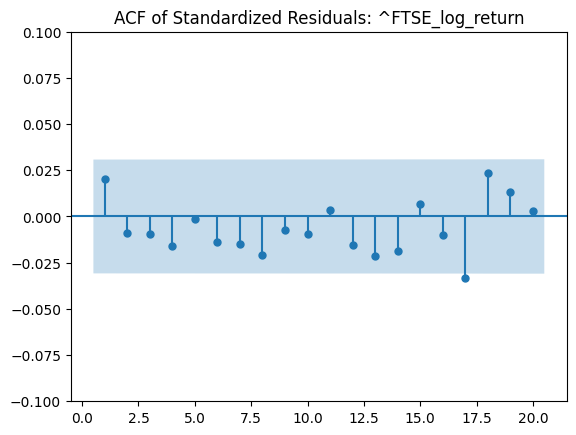

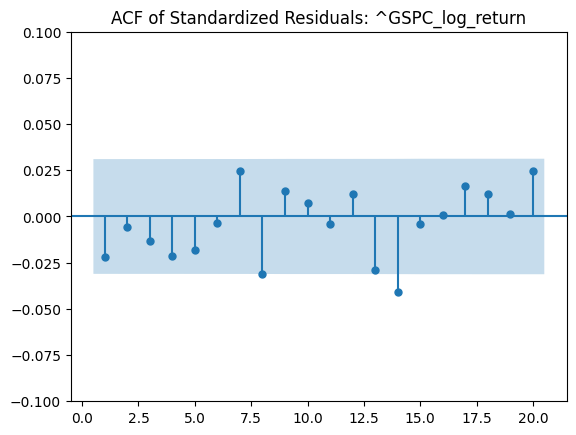

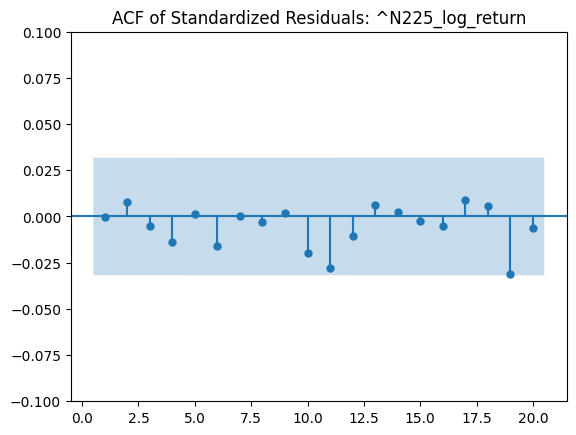

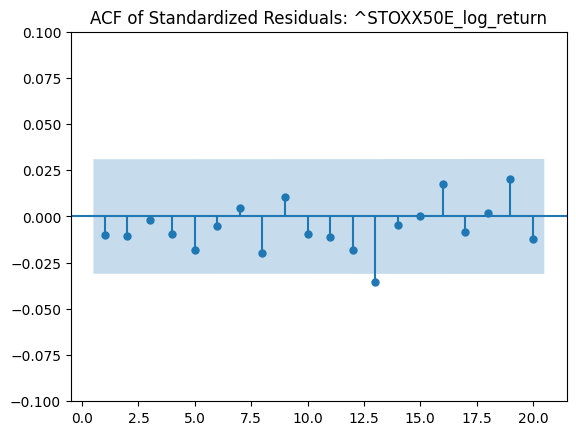

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
for key, result in garch_results.items():
    resid = result.resid
    cond_vol = result.conditional_volatility
    std_resid = (resid / cond_vol).dropna()
    plot_acf(std_resid, lags=20,zero=False)
    plt.title(f"ACF of Standardized Residuals: {key}")
    safe_key = key.replace('^', '').replace('_log_return', '').lower()
    plt.ylim(-0.1,0.1)
    # Export: ../outputs/acf_standardized_residuals_<index>.png
    plt.savefig(OUTPUT_DIR / f'acf_standardized_residuals_{safe_key}.png', dpi=300, bbox_inches='tight')
    plt.show()

## Interpretation of the ACF of Standardized Residuals

The autocorrelation functions (ACFs) of the standardized residuals for all four indices show very little evidence of serial dependence. Nearly all autocorrelation coefficients fall within the 95% confidence bands and remain close to zero.

This suggests that the GARCH(1,1) model has successfully removed the linear dependence structure from the residual series. In other words, after adjusting for the time-varying conditional volatility estimated by the model, the standardized residuals behave approximately as white noise.

The absence of significant autocorrelation indicates that the model captures the dynamics of the conditional mean and variance reasonably well. Therefore, there is little evidence of remaining predictable structure in the standardized residuals.

Overall, these results provide support for the adequacy of the fitted GARCH(1,1) specification.

## Garch Model Fitting with T-distribution

In [12]:
#Fitting the Model for Each Index
from arch import arch_model
garch_t_results={}
for col in log_return_data.columns:
    returns=log_return_data[col].dropna()
    #here use returns*100 rather than just return for better model fitting
    model=arch_model(returns*100,
                     mean='constant',
                     vol='GARCH',
                     p=1,
                     q=1,
                     dist='studentst')
    result=model.fit(disp='off')
    garch_t_results[col]=result

#Store the fitted parameters for display
summary_table2=pd.DataFrame({
    col:results.params
    for col, results in garch_t_results.items()
}).T
summary_table2['sum of parameters']=summary_table2['alpha[1]']+summary_table2['beta[1]']
# Export: ../outputs/garch_student_t_parameters.csv
summary_table2.to_csv(OUTPUT_DIR / 'garch_student_t_parameters.csv')
summary_table2


,mu,omega,alpha[1],beta[1],nu,sum of parameters
^FTSE_log_return,0.047650,0.040983,0.153584,0.806430,5.745492,0.960013
^GSPC_log_return,0.098932,0.026355,0.166629,0.822001,5.418491,0.988630
^N225_log_return,0.082586,0.086096,0.133979,0.820954,6.128229,0.954933
^STOXX50E_log_return,0.075047,0.042364,0.131994,0.848331,5.452677,0.980325


## Model Comparison: Garch using T-distibution VS. Normal Distribution

In [13]:
# Compare Normal GARCH and Student-t GARCH using AIC and BIC
compare_rows = []
for col in log_return_data.columns:
    compare_rows.append({
        'Index': col,
        'Normal AIC': garch_results[col].aic,
        'Normal BIC': garch_results[col].bic,
        'Student-t AIC': garch_t_results[col].aic,
        'Student-t BIC': garch_t_results[col].bic
    })

compare_table = pd.DataFrame(compare_rows).set_index('Index')

# Export: ../outputs/garch_model_comparison.csv
compare_table.to_csv(OUTPUT_DIR / 'garch_model_comparison.csv')
compare_table

,Normal AIC,Normal BIC,Student-t AIC,Student-t BIC
Index,,,,
^FTSE_log_return,10071.598374,10096.823275,9859.610116,9891.141242
^GSPC_log_return,10267.416178,10292.576344,10029.578787,10061.028995
^N225_log_return,12228.412650,12253.387884,12048.041863,12079.260905
^STOXX50E_log_return,12090.680624,12115.855822,11850.515474,11881.984472


Note that the Student-t AIC and BIC both show better performance for all 4 indicies, so Student-t distribution should be a better fit in our case. Therefore, we will use Student-t distribution in out Garch model for prediction. 

(Note: There is a small look-ahead bias as our decision of using t-distribution rather than normal is partly from the data we need to use for testing.)

# Model Prediction
We use an expanding-window recursive one-step-ahead forecasting approach. Specifically, for each date in the test period from 2022 onward, we refit the Student-t GARCH(1,1) model using only the return data available up to the previous date, and then generate a one-step-ahead forecast of the next day’s conditional volatility.

This procedure is repeated sequentially throughout the test sample, so each forecast is made using only information that would have been available at that time. In this way, the forecasting exercise avoids look-ahead bias and better reflects a real-time prediction setting.

To evaluate the forecasts, we compare the model-implied volatility with a realized proxy constructed from returns. Since true latent volatility is unobservable, we use $r_t^2$ as a proxy for realized variance. In the final comparison with the forecasted conditional standard deviation, we use $|r_t| = \sqrt{r_t^2}$ as a proxy for realized volatility.

In [ ]:
# Train-test split
train = log_return_data[log_return_data.index < '2022-01-01']
test = log_return_data[log_return_data.index >= '2022-01-01']

# Store recursive one-step-ahead forecasts for each index.
recursive_forecasts = {}

for col in log_return_data.columns:
    full_series = log_return_data[col].dropna()
    test_dates = test[col].dropna().index
    forecast_rows = []

    for forecast_date in test_dates:
        history = full_series[full_series.index < forecast_date]
        model = arch_model(
            history * 100,
            mean='constant',
            vol='GARCH',
            p=1,
            q=1,
            dist='studentst'
        )
        result = model.fit(disp='off')
        forecast = result.forecast(horizon=1, reindex=False)
        forecast_variance = forecast.variance.iloc[-1, 0]
        forecast_volatility = np.sqrt(forecast_variance)
        realized_variance = (full_series.loc[forecast_date] * 100)**2

        forecast_rows.append(
            {
                'Date': forecast_date,
                'forecast_volatility': forecast_volatility,
                'realized_variance': realized_variance,
            }
        )

    recursive_forecasts[col] = pd.DataFrame(forecast_rows).set_index('Date')
    safe_key = col.replace('^', '').replace('_log_return', '').lower()
    # Export: ../outputs/recursive_forecast_<index>.csv
    recursive_forecasts[col].to_csv(OUTPUT_DIR / f'recursive_forecast_{safe_key}.csv')

recursive_forecasts


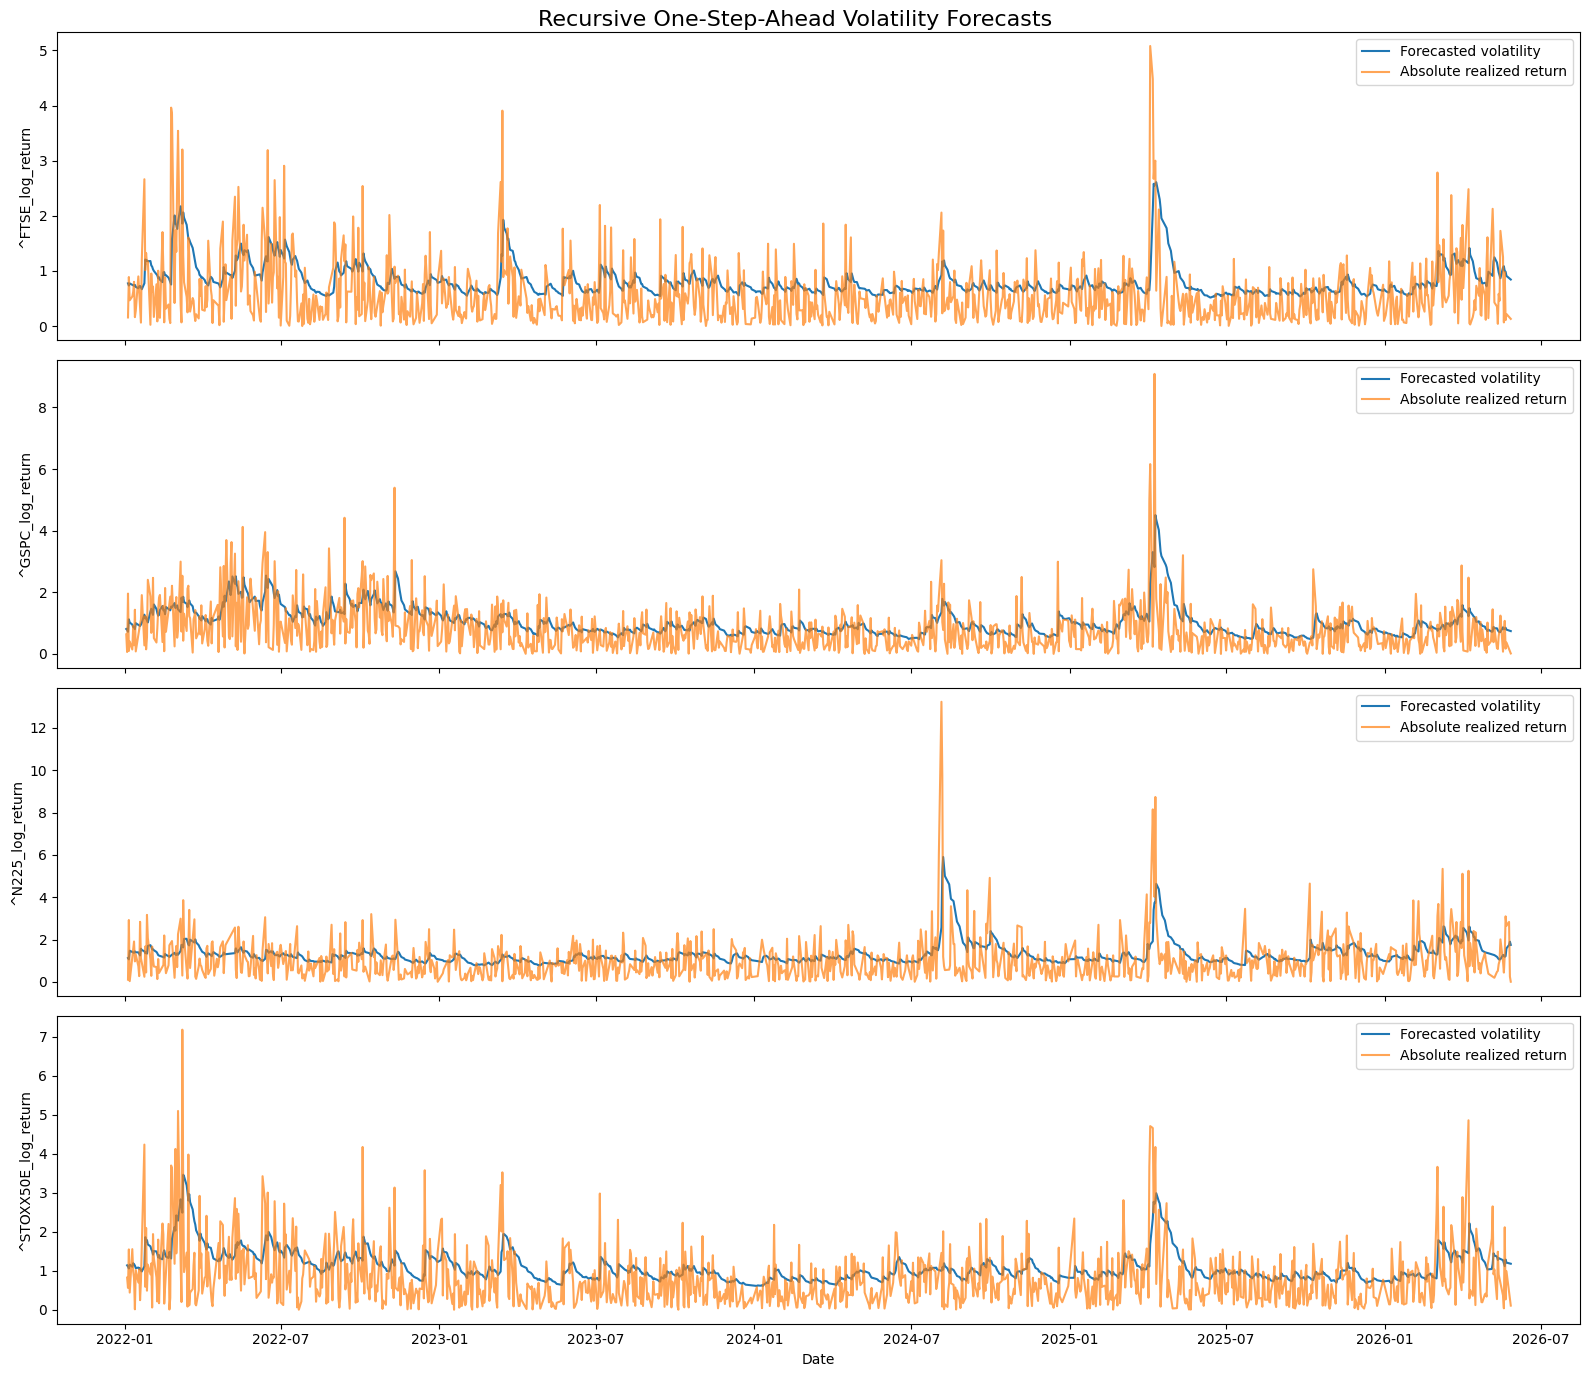

In [ ]:
# Forecast summary and plots
forecast_summary = []
for col, forecast_df in recursive_forecasts.items():
    realized_abs_return = np.sqrt(forecast_df['realized_variance'])/100
    volatility_error = (forecast_df['forecast_volatility'] - realized_abs_return)/100

    forecast_summary.append(
        {
            'Index': col,
            'Forecast Start': forecast_df.index.min(),
            'Forecast End': forecast_df.index.max(),
            'Observations': len(forecast_df),
            'Mean Forecast Volatility': forecast_df['forecast_volatility'].mean()/100,
            'Mean Realized Absolute Return': realized_abs_return.mean(),
            'Volatility RMSE': np.sqrt((volatility_error ** 2).mean()),
        }
    )

forecast_summary = pd.DataFrame(forecast_summary).set_index('Index')
# Export: ../outputs/forecast_summary.csv
forecast_summary.to_csv(OUTPUT_DIR / 'forecast_summary.csv')
forecast_summary

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Recursive One-Step-Ahead Volatility Forecasts', fontsize=16)
axes = axes.flatten()

for i, (col, forecast_df) in enumerate(recursive_forecasts.items()):
    realized_abs_return = np.sqrt(forecast_df['realized_variance'])/100
    axes[i].plot(
        forecast_df.index,
        forecast_df['forecast_volatility']/100,
        label='Forecasted volatility',
    )
    axes[i].plot(
        forecast_df.index,
        realized_abs_return,
        label='Absolute realized return',
        alpha=0.7,
    )
    axes[i].set_ylabel(col)
    axes[i].legend()

plt.xlabel('Date')
plt.tight_layout()
# Export: ../outputs/recursive_one_step_ahead_volatility_forecasts.png
plt.savefig(OUTPUT_DIR / 'recursive_one_step_ahead_volatility_forecasts.png', dpi=300, bbox_inches='tight')
plt.show()
